In [61]:
import os

folder = "/kaggle/input/datasets/azalhowaide/iot-dataset-for-intrusion-detection-systems-ids"
for root, dirs, files in os.walk(folder):
    for f in files:
        print(os.path.join(root, f))

/kaggle/input/datasets/azalhowaide/iot-dataset-for-intrusion-detection-systems-ids/BotNeTIoT-L01_label_NoDuplicates.csv
/kaggle/input/datasets/azalhowaide/iot-dataset-for-intrusion-detection-systems-ids/BoTNeTIoT-L01-v2.csv


In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)

In [63]:
df = pd.read_csv("/kaggle/input/datasets/azalhowaide/iot-dataset-for-intrusion-detection-systems-ids/BoTNeTIoT-L01-v2.csv")
df.shape

(7062606, 27)

In [64]:
df.head()

,MI_dir_L0.1_weight,MI_dir_L0.1_mean,MI_dir_L0.1_variance,H_L0.1_weight,H_L0.1_mean,H_L0.1_variance,HH_L0.1_weight,HH_L0.1_mean,HH_L0.1_std,HH_L0.1_magnitude,...,HpHp_L0.1_mean,HpHp_L0.1_std,HpHp_L0.1_magnitude,HpHp_L0.1_radius,HpHp_L0.1_covariance,HpHp_L0.1_pcc,Device_Name,Attack,Attack_subType,label
0,1.000000,98.000000,0.000000e+00,1.000000,98.000000,0.000000e+00,1.00000,98.0,0.000000e+00,98.000000,...,98.0,0.000000,98.000000,0.000000e+00,0.0,0.0,Danmini_Doorbell,gafgyt,combo,0
1,1.931640,98.000000,1.818989e-12,1.931640,98.000000,1.818989e-12,1.93164,98.0,1.348699e-06,138.592929,...,98.0,0.000001,138.592929,1.818989e-12,0.0,0.0,Danmini_Doorbell,gafgyt,combo,0
2,2.904273,86.981750,2.311822e+02,2.904273,86.981750,2.311822e+02,1.00000,66.0,0.000000e+00,114.856432,...,66.0,0.000000,114.856432,0.000000e+00,0.0,0.0,Danmini_Doorbell,gafgyt,combo,0
3,3.902546,83.655268,2.040614e+02,3.902546,83.655268,2.040614e+02,1.00000,74.0,0.000000e+00,74.000000,...,74.0,0.000000,74.000000,0.000000e+00,0.0,0.0,Danmini_Doorbell,gafgyt,combo,0
4,4.902545,81.685828,1.775746e+02,4.902545,81.685828,1.775746e+02,2.00000,74.0,9.536743e-07,74.000000,...,74.0,0.000000,74.000000,0.000000e+00,0.0,0.0,Danmini_Doorbell,gafgyt,combo,0


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7062606 entries, 0 to 7062605
Data columns (total 27 columns):
 #   Column                Dtype  
---  ------                -----  
 0   MI_dir_L0.1_weight    float64
 1   MI_dir_L0.1_mean      float64
 2   MI_dir_L0.1_variance  float64
 3   H_L0.1_weight         float64
 4   H_L0.1_mean           float64
 5   H_L0.1_variance       float64
 6   HH_L0.1_weight        float64
 7   HH_L0.1_mean          float64
 8   HH_L0.1_std           float64
 9   HH_L0.1_magnitude     float64
 10  HH_L0.1_radius        float64
 11  HH_L0.1_covariance    float64
 12  HH_L0.1_pcc           float64
 13  HH_jit_L0.1_weight    float64
 14  HH_jit_L0.1_mean      float64
 15  HH_jit_L0.1_variance  float64
 16  HpHp_L0.1_weight      float64
 17  HpHp_L0.1_mean        float64
 18  HpHp_L0.1_std         float64
 19  HpHp_L0.1_magnitude   float64
 20  HpHp_L0.1_radius      float64
 21  HpHp_L0.1_covariance  float64
 22  HpHp_L0.1_pcc         float64
 23  Device_

In [66]:
df.isnull().sum()

MI_dir_L0.1_weight      0
MI_dir_L0.1_mean        0
MI_dir_L0.1_variance    0
H_L0.1_weight           0
H_L0.1_mean             0
H_L0.1_variance         0
HH_L0.1_weight          0
HH_L0.1_mean            0
HH_L0.1_std             0
HH_L0.1_magnitude       0
HH_L0.1_radius          0
HH_L0.1_covariance      0
HH_L0.1_pcc             0
HH_jit_L0.1_weight      0
HH_jit_L0.1_mean        0
HH_jit_L0.1_variance    0
HpHp_L0.1_weight        0
HpHp_L0.1_mean          0
HpHp_L0.1_std           0
HpHp_L0.1_magnitude     0
HpHp_L0.1_radius        0
HpHp_L0.1_covariance    0
HpHp_L0.1_pcc           0
Device_Name             0
Attack                  0
Attack_subType          0
label                   0
dtype: int64

In [67]:
#Duplicates handling 
before = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
after = df.shape[0]
print(f"Rows before: {before:}")
print(f"Rows after:  {after:}")

Rows before: 7062606
Rows after:  6440947


Features statisics (skewness and outliers handling) 

In [68]:
FEATURE_COLS = [c for c in df.columns if c not in ["Device_Name", "Attack", "Attack_subType", "label"]]
CAT_COLS = ["Device_Name", "Attack", "Attack_subType"]

desc = df[FEATURE_COLS].describe().T
desc["skew"] = df[FEATURE_COLS].skew()
desc["kurtosis"] = df[FEATURE_COLS].kurtosis()
desc.round(4)

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
MI_dir_L0.1_weight,6440947.0,3.728633e+03,2.825027e+03,1.0000,10.9495,4076.4013,6.383311e+03,8.946997e+03,-0.1880,-1.5793
MI_dir_L0.1_mean,6440947.0,1.906208e+02,1.563308e+02,60.0000,60.0968,74.5639,3.799362e+02,1.401994e+03,0.5842,-1.2520
MI_dir_L0.1_variance,6440947.0,2.109423e+04,2.675759e+04,0.0000,1.6650,281.6700,5.031722e+04,4.520011e+05,0.9414,3.5721
H_L0.1_weight,6440947.0,3.728633e+03,2.825027e+03,1.0000,10.9495,4076.4013,6.383311e+03,8.946997e+03,-0.1880,-1.5793
H_L0.1_mean,6440947.0,1.906210e+02,1.563309e+02,60.0000,60.0968,74.5639,3.799363e+02,1.401994e+03,0.5842,-1.2520
H_L0.1_variance,6440947.0,2.109425e+04,2.675758e+04,0.0000,1.6652,281.6863,5.031722e+04,4.520011e+05,0.9414,3.5721
HH_L0.1_weight,6440947.0,2.074784e+03,2.569486e+03,1.0000,1.0000,2.1937,4.356863e+03,7.944987e+03,0.7509,-0.8830
HH_L0.1_mean,6440947.0,1.904141e+02,2.121425e+02,60.0000,60.0000,73.9967,3.300000e+02,1.470000e+03,1.1537,-0.5529
HH_L0.1_std,6440947.0,4.603500e+00,2.234800e+01,0.0000,0.0000,0.0765,4.064900e+00,6.784580e+02,11.9749,190.3801
HH_L0.1_magnitude,6440947.0,1.979141e+02,2.123536e+02,60.0000,60.0000,73.9989,4.372030e+02,1.470000e+03,1.1366,-0.4030


In [69]:
zero_var_cols = desc[desc["std"] == 0].index.tolist()
high_skew_cols = desc[desc["skew"].abs() > 3].index.tolist()

print(f"Zero-variance features: {len(zero_var_cols)}")
if zero_var_cols:
    print(zero_var_cols)

print(f"\nHighly skewed features (|skew| > 3): {len(high_skew_cols)}")
if high_skew_cols:
    print(high_skew_cols)

Zero-variance features: 0

Highly skewed features (|skew| > 3): 10
['HH_L0.1_std', 'HH_L0.1_radius', 'HH_L0.1_covariance', 'HH_L0.1_pcc', 'HH_jit_L0.1_variance', 'HpHp_L0.1_weight', 'HpHp_L0.1_std', 'HpHp_L0.1_radius', 'HpHp_L0.1_covariance', 'HpHp_L0.1_pcc']


log-transform the highly skewed features

In [70]:
for col in high_skew_cols:
    shift = -df[col].min() + 1 if df[col].min() <= 0 else 0
    df[col] = np.log1p(df[col] + shift)

print(f"Log-transformed {len(high_skew_cols)} columns.")
df[high_skew_cols].skew().round(3)

Log-transformed 10 columns.


HH_L0.1_std               1.952
HH_L0.1_radius            2.174
HH_L0.1_covariance     -286.420
HH_L0.1_pcc               4.015
HH_jit_L0.1_variance      0.532
HpHp_L0.1_weight          4.081
HpHp_L0.1_std             7.062
HpHp_L0.1_radius          6.052
HpHp_L0.1_covariance    -69.435
HpHp_L0.1_pcc             2.384
dtype: float64

In [71]:
#Outliers Check
def iqr_bounds(series: pd.Series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr


def iqr_outlier_pct(series: pd.Series) -> float:
    lower, upper = iqr_bounds(series)
    return ((series < lower) | (series > upper)).mean() * 100


outlier_before = df[FEATURE_COLS].apply(iqr_outlier_pct).sort_values(ascending=False)
outlier_before.round(2).to_frame("outlier_pct").head(10)

,outlier_pct
HpHp_L0.1_weight,19.96
HH_L0.1_pcc,17.42
HpHp_L0.1_radius,15.84
HpHp_L0.1_std,15.07
HH_L0.1_covariance,5.32
HpHp_L0.1_pcc,3.67
HpHp_L0.1_covariance,2.98
HH_L0.1_radius,2.73
HH_L0.1_std,1.65
HpHp_L0.1_magnitude,0.06


Outliers Handling 

In [72]:
capped_cols = []
for col in FEATURE_COLS:
    lower, upper = iqr_bounds(df[col])
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    if n_out > 0:
        df[col] = df[col].clip(lower, upper)
        capped_cols.append(col)

print(f"Capped {len(capped_cols)} of {len(FEATURE_COLS)} features to their IQR bounds "
      f"(values clipped in place, no rows removed, shape still {df.shape}).")

Capped 17 of 23 features to their IQR bounds (values clipped in place, no rows removed, shape still (6440947, 27)).


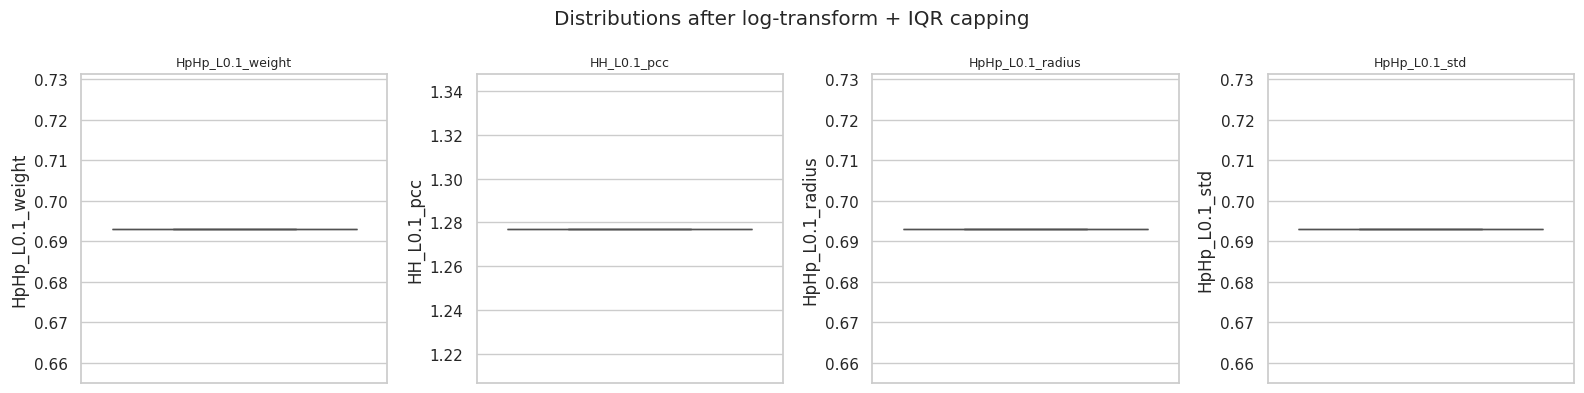

In [73]:
top_outlier_cols = outlier_before.head(4).index.tolist()

fig, axes = plt.subplots(1, len(top_outlier_cols), figsize=(16, 4))
for ax, col in zip(axes, top_outlier_cols):
    sns.boxplot(y=df[col], ax=ax, color="#3498db")
    ax.set_title(col, fontsize=9)
plt.suptitle("Distributions after log-transform + IQR capping")
plt.tight_layout()
plt.show()

In [74]:
# df.to_csv("/kaggle/working/BoTNeTIoT_cleaned.csv", index=False)
# print(f"Saved cleaned dataset: {df.shape[0]} rows, {df.shape[1]} columns")

In [75]:
# from IPython.display import FileLink
# FileLink("BoTNeTIoT_cleaned.csv")

### One-hot encoding for `Device_Name` (kept separate, not merged into `df`)
Produced as its own frame rather than joined onto the 7M-row `df`, to avoid bloating memory with columns you're not meant to train on directly. Available if a specific analysis needs it (e.g. per-device breakdown plots), but — same caveat as above — not for the model's `FEATURE_COLS`.

In [80]:
device_dummies = pd.get_dummies(df["Device_Name"], prefix="device").astype(int)
print(f"One-hot encoded Device_Name into {device_dummies.shape[1]}")

One-hot encoded Device_Name into 9


In [81]:
device_dummies

,device_Danmini_Doorbell,device_Ecobee_Thermostat,device_Ennio_Doorbell,device_Philips_B120N10_Baby_Monitor,device_Provision_PT_737E_Security_Camera,device_Provision_PT_838_Security_Camera,device_Samsung_SNH_1011_N_Webcam,device_SimpleHome_XCS7_1002_WHT_Security_Camera,device_SimpleHome_XCS7_1003_WHT_Security_Camera
0,1,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...
6440942,0,0,0,0,0,0,0,0,1
6440943,0,0,0,0,0,0,0,0,1
6440944,0,0,0,0,0,0,0,0,1
6440945,0,0,0,0,0,0,0,0,1


In [82]:
df_training = df.drop(columns = CAT_COLS)
df_training

,MI_dir_L0.1_weight,MI_dir_L0.1_mean,MI_dir_L0.1_variance,H_L0.1_weight,H_L0.1_mean,H_L0.1_variance,HH_L0.1_weight,HH_L0.1_mean,HH_L0.1_std,HH_L0.1_magnitude,...,HH_jit_L0.1_mean,HH_jit_L0.1_variance,HpHp_L0.1_weight,HpHp_L0.1_mean,HpHp_L0.1_std,HpHp_L0.1_magnitude,HpHp_L0.1_radius,HpHp_L0.1_covariance,HpHp_L0.1_pcc,label
0,1.000000,98.000000,0.000000e+00,1.000000,98.000000,0.000000e+00,1.000000,98.0,0.693147,98.000000,...,1.505914e+09,0.693147,0.693147,98.0,0.693147,98.000000,0.693147,11.785236,1.277168,0
1,1.931640,98.000000,1.818989e-12,1.931640,98.000000,1.818989e-12,1.931640,98.0,0.693148,138.592929,...,7.263102e+08,40.877785,0.693147,98.0,0.693147,138.592929,0.693147,11.785236,1.277168,0
2,2.904273,86.981750,2.311822e+02,2.904273,86.981750,2.311822e+02,1.000000,66.0,0.693147,114.856432,...,1.505914e+09,0.693147,0.693147,66.0,0.693147,114.856432,0.693147,11.785236,1.277168,0
3,3.902546,83.655268,2.040614e+02,3.902546,83.655268,2.040614e+02,1.000000,74.0,0.693147,74.000000,...,1.505914e+09,0.693147,0.693147,74.0,0.693147,74.000000,0.693147,11.785236,1.277168,0
4,4.902545,81.685828,1.775746e+02,4.902545,81.685828,1.775746e+02,2.000000,74.0,0.693148,74.000000,...,7.529571e+08,40.879038,0.693147,74.0,0.693147,74.000000,0.693147,11.785236,1.277168,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6440942,2.801727,294.039965,8.416085e+03,2.801727,294.039965,8.416085e+03,1.214290,330.0,0.693149,431.490440,...,2.502478e+01,0.693266,0.693147,330.0,0.693147,431.490440,0.693147,11.785236,1.277168,1
6440943,2.979945,215.501627,1.780468e+04,2.979945,215.501627,1.780468e+04,1.252204,60.0,0.693147,84.852814,...,2.399763e+01,2.801110,0.693147,60.0,0.693147,84.852814,0.693147,11.785236,1.277168,1
6440944,1.743927,281.157093,1.080196e+04,1.743927,281.157093,1.080196e+04,1.214226,330.0,0.693147,431.490440,...,2.502834e+01,0.693170,0.693147,330.0,0.693147,431.490440,0.693147,11.785236,1.277168,1
6440945,2.743925,298.957472,7.417844e+03,2.743925,298.957472,7.417844e+03,1.214226,330.0,0.693150,431.490440,...,2.502833e+01,0.693170,0.693147,330.0,0.693147,431.490440,0.693147,11.785236,1.277168,1
